# Activation plot

Tracking activation in 2025/26

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [6]:
from datetime import datetime

import ocha_stratus as stratus
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

from src.datasources import grdc
from src.utils.rating_curve import calculate_stage
from src.constants import *

In [7]:
df_grdc = grdc.load_grdc(station_id=NIAMEY_GRDC_ID)

In [8]:
def date_to_season(date):
    if date.month < 6:
        return date.year - 1
    else:
        return date.year

In [10]:
def set_flood_phase(date):
    if date.month >= 6 and date.month <= 9:
        return "l"
    else:
        return "g"

In [11]:
df_grdc["flood_type"] = df_grdc["time"].apply(set_flood_phase)

In [22]:
df_grdc = df_grdc.rename(columns={"time": "date"})

In [17]:
df_grdc["level"] = calculate_stage(df_grdc["runoff_mean"])

In [75]:
df_grdc = df_grdc.dropna(subset="level")
df_grdc["source"] = "grdc"

In [102]:
df_monitoring_2024 = abn.load_current_monitoring()

In [103]:
df_monitoring_2024 = df_monitoring_2024.dropna(subset="level")

In [104]:
df_monitoring_2024["source"] = "abn"

In [105]:
READINESS_THRESH = 592
ACTION_THRESH = 605

In [106]:
df_historical = pd.concat([df_grdc, df_monitoring_2024])

In [107]:
df_historical

,date,runoff_mean,season,flood_type,level,monitoring,source
0,1929-01-01,1691.160034,1928.0,g,568.764994,historical,grdc
5,1929-01-06,1691.160034,1928.0,g,568.764994,historical,grdc
6,1929-01-07,1704.810059,1928.0,g,570.806215,historical,grdc
7,1929-01-08,1704.810059,1928.0,g,570.806215,historical,grdc
8,1929-01-09,1725.270020,1928.0,g,573.850815,historical,grdc
...,...,...,...,...,...,...,...
84,2025-01-19,NaN,NaN,NaN,632.000000,NaN,abn
85,2025-01-20,NaN,NaN,NaN,634.000000,NaN,abn
86,2025-01-21,NaN,NaN,NaN,635.000000,NaN,abn
87,2025-01-22,NaN,NaN,NaN,636.000000,NaN,abn


In [108]:
def set_plot_date(row):
    try:
        if row["date"].year == row["season"]:
            return datetime(1900, row["date"].month, row["date"].day)
        else:
            return datetime(1901, row["date"].month, row["date"].day)

    except Exception as e:
        print(e)
        print(row["date"])

In [109]:
df_historical["season"] = df_historical["date"].apply(date_to_season)
df_historical["plot_date"] = df_historical.apply(set_plot_date, axis=1)
df_historical["flood_type"] = df_historical["date"].apply(set_flood_phase)

day is out of range for month
1932-02-29 00:00:00
day is out of range for month
1936-02-29 00:00:00
day is out of range for month
1944-02-29 00:00:00
day is out of range for month
1948-02-29 00:00:00
day is out of range for month
1952-02-29 00:00:00
day is out of range for month
1956-02-29 00:00:00
day is out of range for month
1960-02-29 00:00:00
day is out of range for month
1964-02-29 00:00:00
day is out of range for month
1968-02-29 00:00:00
day is out of range for month
1972-02-29 00:00:00
day is out of range for month
1976-02-29 00:00:00
day is out of range for month
1980-02-29 00:00:00
day is out of range for month
1984-02-29 00:00:00
day is out of range for month
1988-02-29 00:00:00
day is out of range for month
1992-02-29 00:00:00
day is out of range for month
1996-02-29 00:00:00
day is out of range for month
2000-02-29 00:00:00
day is out of range for month
2004-02-29 00:00:00
day is out of range for month
2008-02-29 00:00:00
day is out of range for month
2012-02-29 00:00:00


In [110]:
df_historical = df_historical.sort_values(
    by="source", ascending=False, key=lambda s: s.eq("abn")
)

# Drop duplicates, keeping the first occurrence (which will be "abn" if present)
df_historical = df_historical.drop_duplicates(subset="date", keep="first")

In [111]:
df_historical = df_historical.sort_values("date")

In [113]:
df_monitoring_2025 = abn.load_current_monitoring(year=2025)

In [114]:
df_monitoring_2025

,date,level
0,2025-11-01,534.5
1,2025-11-02,537.5
2,2025-11-03,538.0
3,2025-11-04,538.0
4,2025-11-05,539.0
5,2025-11-06,542.0
6,2025-11-07,544.0
7,2025-11-08,544.0
8,2025-11-09,545.0
9,2025-11-10,547.0


In [125]:
df_combined = pd.concat([df_historical, df_monitoring_2025], ignore_index=True)

In [126]:
df_combined["season"] = df_combined["date"].apply(date_to_season)
df_combined["plot_date"] = df_combined.apply(set_plot_date, axis=1)
df_combined["flood_type"] = df_combined["date"].apply(set_flood_phase)

day is out of range for month
1932-02-29 00:00:00
day is out of range for month
1936-02-29 00:00:00
day is out of range for month
1944-02-29 00:00:00
day is out of range for month
1948-02-29 00:00:00
day is out of range for month
1952-02-29 00:00:00
day is out of range for month
1956-02-29 00:00:00
day is out of range for month
1960-02-29 00:00:00
day is out of range for month
1964-02-29 00:00:00
day is out of range for month
1968-02-29 00:00:00
day is out of range for month
1972-02-29 00:00:00
day is out of range for month
1976-02-29 00:00:00
day is out of range for month
1980-02-29 00:00:00
day is out of range for month
1984-02-29 00:00:00
day is out of range for month
1988-02-29 00:00:00
day is out of range for month
1992-02-29 00:00:00
day is out of range for month
1996-02-29 00:00:00
day is out of range for month
2000-02-29 00:00:00
day is out of range for month
2004-02-29 00:00:00
day is out of range for month
2008-02-29 00:00:00
day is out of range for month
2012-02-29 00:00:00


In [127]:
gui_df = df_combined[df_combined["flood_type"] == "g"]

In [128]:
gui_df.loc[
    gui_df[gui_df["level"] >= READINESS_THRESH]
    .groupby("season")["date"]
    .idxmin()
]

,date,runoff_mean,season,flood_type,level,monitoring,source,plot_date
17,1929-01-31,1868.530029,1928,g,594.689912,historical,grdc,1901-01-31
293,1930-01-18,1861.709961,1929,g,593.716045,historical,grdc,1901-01-18
593,1931-01-15,1854.880005,1930,g,592.739005,historical,grdc,1901-01-15
4787,1951-01-28,1855.410034,1950,g,592.814890,historical,grdc,1901-01-28
5170,1952-02-15,1855.410034,1951,g,592.814890,historical,grdc,1901-02-15
5504,1953-01-14,1859.810059,1952,g,593.444437,historical,grdc,1901-01-14
5858,1954-01-03,1859.810059,1953,g,593.444437,historical,grdc,1901-01-03
6223,1955-01-03,1851.890015,1954,g,592.310724,historical,grdc,1901-01-03
6577,1955-12-23,1851.890015,1955,g,592.310724,historical,grdc,1900-12-23
7329,1958-01-13,1851.890015,1957,g,592.310724,historical,grdc,1901-01-13


In [129]:
def custom_date_formatter(x, pos):
    date = mdates.num2date(x)  # Convert numeric value to date
    month_abbr = date.strftime(
        "%b"
    )  # Get abbreviated month name (e.g., "Jan", "Feb")
    day = date.day  # Get day of the month
    translated_month = FRENCH_MONTHS.get(
        month_abbr, month_abbr
    )  # Translate month
    return f"{day} {translated_month}"  # Format as "Translated Month Day"

Text(0.5, 1.0, 'Fleuve Niger à Niamey\nCrues guinéennes (depuis 2000)')

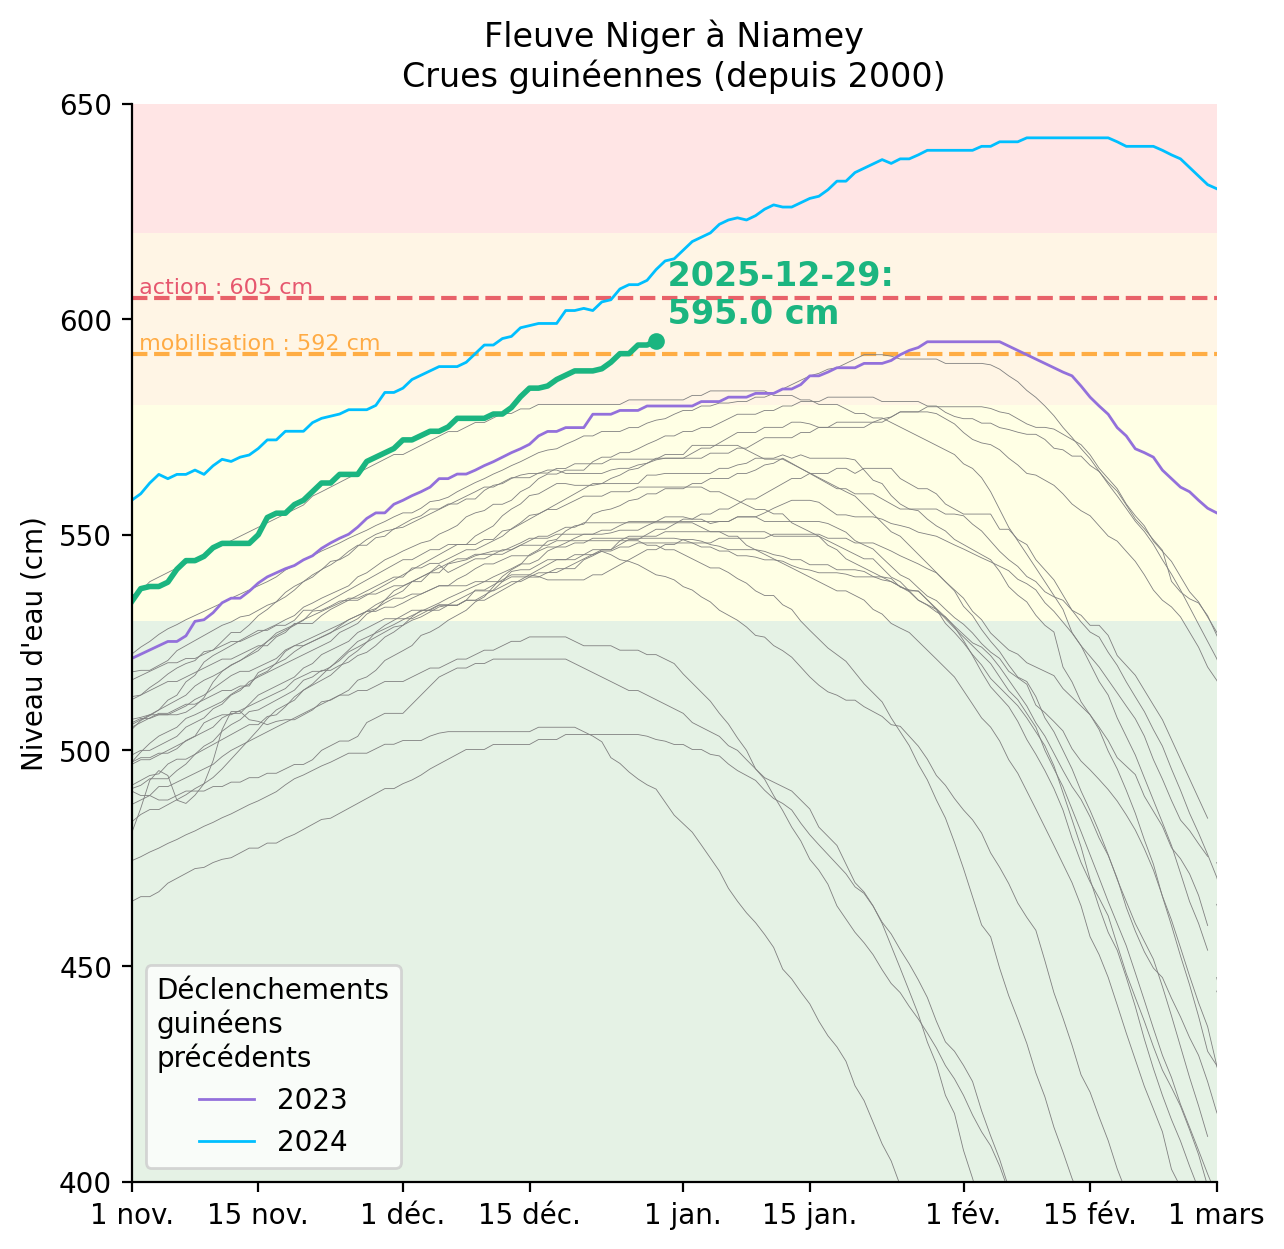

In [156]:
min_year = 2000

fig, ax = plt.subplots(dpi=200, figsize=(7, 7))

seasonyear_colors = {
    2022: "mediumpurple",
    2024: "deepskyblue",
}

for seasonyear in gui_df["season"].unique():
    if seasonyear < min_year:
        continue
    dff = (
        gui_df[gui_df["season"] == seasonyear].copy().dropna(subset=["level"])
    )
    if seasonyear == 2025:
        color = CHD_GREEN
        label = None
        width = 2
    elif seasonyear in seasonyear_colors:
        color = seasonyear_colors.get(seasonyear)
        label = dff[dff["level"] >= READINESS_THRESH]["date"].min().year
        width = 1
    else:
        color = "grey"
        label = None
        width = 0.3
    ax.plot(
        dff["plot_date"],
        dff["level"],
        color=color,
        label=label,
        linewidth=width,
    )

latest_row = gui_df.loc[gui_df["date"].idxmax()]
ax.annotate(
    f' {latest_row["date"].date()}:\n {latest_row["level"]} cm',
    (latest_row["plot_date"], latest_row["level"] + 4),
    color=CHD_GREEN,
    fontsize=12,
    fontweight="bold",
)
ax.plot(
    latest_row["plot_date"],
    latest_row["level"],
    color=CHD_GREEN,
    marker=".",
    markersize=10,
)

ax.legend(title="Déclenchements\nguinéens\nprécédents", loc="lower left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Niveau d'eau (cm)")
ax.set_xlim(left=datetime(1900, 11, 1), right=datetime(1901, 3, 1))
ax.set_ylim(bottom=400, top=650)

ax.axhspan(0, 530, facecolor="green", alpha=0.1)
ax.axhspan(530, 580, facecolor="yellow", alpha=0.1)
ax.axhspan(580, 620, facecolor="orange", alpha=0.1)
ax.axhspan(620, 700, facecolor="red", alpha=0.1)

alpha = 0.7
for thresh, color, label in [
    (ACTION_THRESH, "crimson", "action"),
    (READINESS_THRESH, "darkorange", "mobilisation"),
]:
    ax.axhline(thresh, color=color, linestyle="--", zorder=-1, alpha=alpha)
    ax.annotate(
        f" {label} : {thresh} cm",
        (datetime(1900, 11, 1), thresh),
        ha="left",
        va="bottom",
        color=color,
        fontsize=8,
        alpha=alpha,
    )

# French dates formatting
ax.xaxis.set_major_formatter(ticker.FuncFormatter(custom_date_formatter))

ax.set_title(f"Fleuve Niger à Niamey\nCrues guinéennes (depuis {min_year})")

In [155]:
gui_df[
    (gui_df["plot_date"] == "1900-11-01") & (gui_df["season"] >= 2000)
].sort_values("level", ascending=False)

,date,runoff_mean,season,flood_type,level,monitoring,source,plot_date
31686,2024-11-01,NaN,2024,g,558.000000,NaN,abn,1900-11-01
24047,2003-11-01,1478.900024,2003,g,535.914965,historical,grdc,1900-11-01
31915,2025-11-01,NaN,2025,g,534.500000,NaN,NaN,1900-11-01
29526,2018-11-01,1395.000000,2018,g,522.296821,historical,grdc,1900-11-01
30987,2022-11-01,1389.000000,2022,g,521.307768,historical,grdc,1900-11-01
27335,2012-11-01,1370.099976,2012,g,518.178507,historical,grdc,1900-11-01
30257,2020-11-01,1359.000000,2020,g,516.330845,historical,grdc,1900-11-01
25143,2006-11-01,1335.911011,2006,g,512.463738,historical,grdc,1900-11-01
25508,2007-11-01,1331.733032,2007,g,511.760499,historical,grdc,1900-11-01
30622,2021-11-01,1304.750000,2021,g,507.192484,historical,grdc,1900-11-01
